In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/wendtris/S-wendtris12D.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 20  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 4
Number of requests per episode (T_d): 20
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10]
Instance: [[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79,

In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [54, 1, 1, 0, 0]
  Anfrage 2: [18, 1, 1, 0, 0]
  Anfrage 3: [73, 1, 1, 0, 0]
  Anfrage 4: [15, 1, 1, 0, 0]
  Anfrage 5: [88, 2, 1, 0, 0]
  Anfrage 6: [18, 2, 1, 0, 0]
  Anfrage 7: [13, 1, 1, 0, 0]
  Anfrage 8: [97, 1, 1, 0, 0]
  Anfrage 9: [20, 1, 3, 0, 0]
  Anfrage 10: [84, 1, 1, 0, 0]
  Anfrage 11: [71, 1, 1, 0, 0]
  Anfrage 12: [74, 1, 2, 0, 0]
  Anfrage 13: [87, 1, 1, 0, 0]
  Anfrage 14: [97, 1, 1, 0, 0]
  Anfrage 15: [47, 3, 1, 0, 0]
  Anfrage 16: [77, 1, 1, 0, 0]
  Anfrage 17: [74, 1, 2, 0, 0]
  Anfrage 18: [25, 1, 3, 0, 0]
  Anfrage 19: [69, 1, 3, 0, 0]
  Anfrage 20: [67, 1, 1, 0, 0]


(array([ 1., 10., 10., 10., 10., 54.,  1.,  1.,  0.,  0.], dtype=float32),
 {'valid_actions': [0, 1, 2, 3]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 88.  2.  1.  0.  0.]
t=2    Caps=[8, 9, 10, 10]  r=74.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[7, 7, 10, 10]  r=21.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[5, 6, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[3, 5, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[2, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
False
t=7    Caps=[0, 3, 10, 10]  r=50.00  q=[3, 2, 0, 0]  Valid Actions: [0, 2, 3]


In [5]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.99, epsilon_decay_steps=5000)

In [6]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=1500)

  Systematic monotonicity (Episode 1): C_k: 72.8%, t: 64.1%, r: 51.2%, q: 71.5%, mixed: 52.7%
Episode   50/1500  Reward:   489.00  Avg(50):   322.24  Tiefe:   20  Avg-Tiefe(50):   20.0  ε: 0.837
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 0.0%, r: 84.8%, q: 15.9%, mixed: 97.9%
Episode  100/1500  Reward:   318.00  Avg(50):   446.08  Tiefe:   10  Avg-Tiefe(50):   19.6  ε: 0.706
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 0.7%, r: 94.6%, q: 0.0%, mixed: 100.0%
Episode  150/1500  Reward:   450.00  Avg(50):   504.38  Tiefe:   20  Avg-Tiefe(50):   19.5  ε: 0.599
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 30.0%, r: 87.4%, q: 0.0%, mixed: 99.2%
Episode  200/1500  Reward:   528.00  Avg(50):   528.14  Tiefe:   20  Avg-Tiefe(50):   18.0  ε: 0.516
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 41.3%, r: 90.5%, q: 0.0%, mixed: 100.0%
Episode  250/1500  Reward:   460.00  Avg(50):   544.60  Tiefe:   14  Avg-Tiefe(50):   18.0  ε: 0.448
  Systematic mono

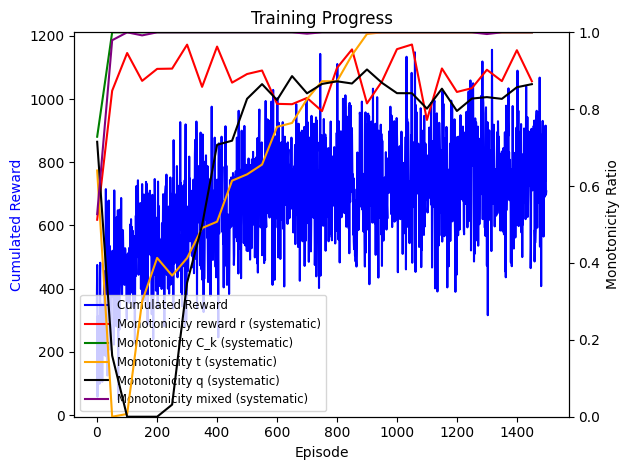

In [7]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

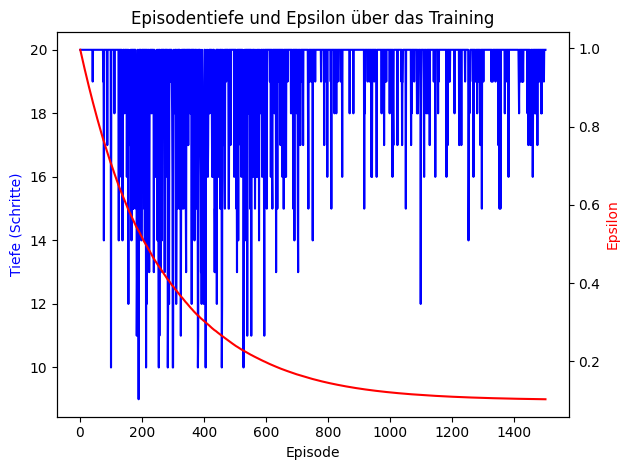

In [8]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [9]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [9, 1, 1, 0, 0]
  Anfrage 2: [70, 1, 3, 0, 0]
  Anfrage 3: [69, 1, 3, 0, 0]
  Anfrage 4: [18, 2, 1, 0, 0]
  Anfrage 5: [67, 1, 1, 0, 0]
  Anfrage 6: [41, 1, 1, 0, 0]
  Anfrage 7: [43, 1, 2, 0, 0]
  Anfrage 8: [63, 3, 2, 0, 0]
  Anfrage 9: [20, 1, 1, 0, 0]
  Anfrage 10: [18, 2, 1, 0, 0]
  Anfrage 11: [8, 1, 1, 0, 0]
  Anfrage 12: [73, 1, 1, 0, 0]
  Anfrage 13: [73, 1, 1, 0, 0]
  Anfrage 14: [50, 3, 2, 0, 0]
  Anfrage 15: [39, 1, 2, 0, 0]
  Anfrage 16: [58, 1, 2, 0, 0]
  Anfrage 17: [62, 1, 1, 0, 0]
  Anfrage 18: [9, 1, 1, 0, 0]
  Anfrage 19: [22, 1, 1, 0, 0]
  Anfrage 20: [41, 1, 1, 0, 0]
Aktion gewählt: 0
t=2    Caps=[10, 10, 10, 10]  r=70.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=3    Caps=[9, 7, 10, 10]  r=69.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=4    Caps=[8, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=5    Caps=[8, 4, 10, 10]  r=67.00  q=[1, 1, 0, 0]  Vali

## Analyse der Reward-History

Diese Zelle berechnet einfache Kennzahlen (Mean, Std, Median, AUC, Final-Mean) aus der vorhandenen `reward_history`-Liste und zeigt einen Plot mit gleitendem Durchschnitt.

Episoden: 1500
Mean: 677.0393, Std: 172.8942, Median: 687.0000
Max: 1156.0000, Min: 50.0000


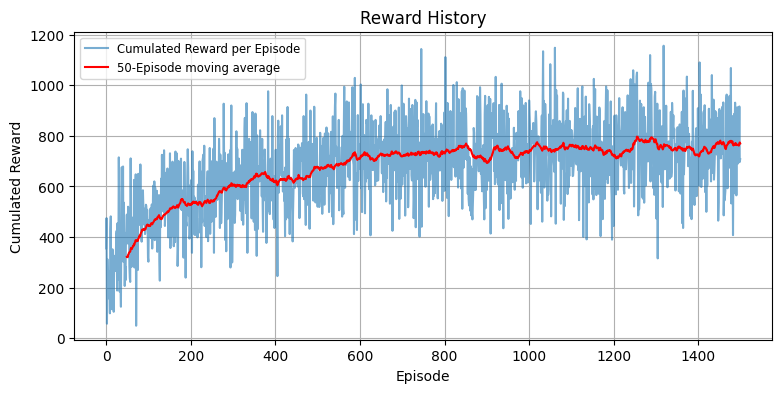

{'n': 1500,
 'mean': 677.0393333333334,
 'std': 172.89419323464392,
 'median': 687.0,
 'max': 1156.0,
 'min': 50.0}

In [11]:
from training.plotting import plot_reward_moving_average
plot_reward_moving_average(reward_history, window=50)

## Evaluationsphase (eingefrorene Parameter, epsilon=0)

Nach abgeschlossenem Training werden die Netzgewichte fixiert (keine weiteren Trainingsschritte, `epsilon=0`, reines Exploitation) und für 10.000 Episoden evaluiert, um eine stabile Schätzung der Performance zu erhalten.

In [12]:
eval_rewards, eval_depths = agent.evaluate(num_episodes=1000)

[Eval] Episode   500/1000  Reward:   811.00  Avg(500):   818.12  Avg-Tiefe(500):   19.5
[Eval] Episode  1000/1000  Reward:   962.00  Avg(500):   824.24  Avg-Tiefe(500):   19.6


Eval-Episoden: 1000
Mean: 821.1780, Std: 124.0625, Median: 824.0000
Max: 1235.0000, Min: 419.0000


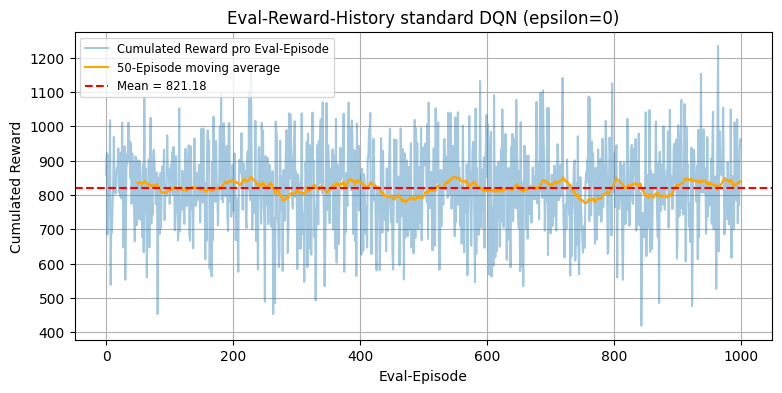

In [13]:
from training.plotting import plot_eval_rewards

eval_stats = plot_eval_rewards(eval_rewards, title="Eval-Reward-History standard DQN (epsilon=0)")